# 🧪 TriFeaturizer: Static preview

This is a **non-interactive preview** that renders on GitHub: it runs the built-in examples and shows the resulting tables, the molecule depiction, and the charts. The buttons, file upload, and batch-to-Excel features live in the interactive notebook — **open `TriFeaturizer.v2.ipynb` in Google Colab** to use those.

The featurization code below is identical to the interactive version; only the widget controls are replaced with direct example calls.

In [ ]:
# @title
# === Preview utilities (no widgets) ==========================================
import pandas as pd
from IPython.display import display, HTML
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight", "font.size": 11})
IN_COLAB = False

def render_feature_table(rows, caption=""):
    df = pd.DataFrame(rows, columns=["Feature", "Value", "What it means"])
    styler = (df.style.hide(axis="index").set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("background-color", "#1f2937"),
            ("color", "white"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px"),
            ("border-bottom", "1px solid #e5e7eb")]}]))
    if caption:
        display(HTML(f"<h4 style='margin:8px 0'>{caption}</h4>"))
    display(styler)

def download_file(filename): pass
def download_dataframe(df, filename): df.to_csv(filename, index=False)
def write_excel(df, filename, failed=None): df.to_excel(filename, index=False)

def save_and_show(fig, filename):
    fig.savefig(filename, dpi=600, bbox_inches="tight")
    plt.show()

## Part 1 · Sequence features  (amino acid · peptide · protein)

**Biopython (`ProtParam`)** supplies the interpretable physico-chemical properties — molecular weight, isoelectric point, net charge, GRAVY hydropathy, aromaticity, instability index, and extinction coefficient. **peptides.py** adds 102 published QSAR descriptors (Kidera, Z-scales, VHSE, BLOSUM indices, and more) that make up the bulk of the full vector. A single residue falls back to a curated reference table.

*Batch mode:* upload a file with a `sequence` column to get the full ≈108-feature matrix for every sequence as an Excel workbook.

In [ ]:
# @title
# === PART 1 \u00b7 Sequence features ===========================================
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import peptides

STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
SEQ_COLS = ["sequence", "seq", "peptide", "protein", "fasta", "sequences"]

# (name, 3-letter, MW, pI, Kyte-Doolittle hydropathy, side-chain class)
AA_TABLE = {
 'A':('Alanine','Ala',89.09,6.00,1.8,'nonpolar'), 'R':('Arginine','Arg',174.20,10.76,-4.5,'positive'),
 'N':('Asparagine','Asn',132.12,5.41,-3.5,'polar'), 'D':('Aspartate','Asp',133.10,2.77,-3.5,'negative'),
 'C':('Cysteine','Cys',121.16,5.07,2.5,'polar'),  'Q':('Glutamine','Gln',146.15,5.65,-3.5,'polar'),
 'E':('Glutamate','Glu',147.13,3.22,-3.5,'negative'),'G':('Glycine','Gly',75.07,5.97,-0.4,'nonpolar'),
 'H':('Histidine','His',155.16,7.59,-3.2,'positive'),'I':('Isoleucine','Ile',131.17,6.02,4.5,'nonpolar'),
 'L':('Leucine','Leu',131.17,5.98,3.8,'nonpolar'), 'K':('Lysine','Lys',146.19,9.74,-3.9,'positive'),
 'M':('Methionine','Met',149.21,5.74,1.9,'nonpolar'),'F':('Phenylalanine','Phe',165.19,5.48,2.8,'nonpolar'),
 'P':('Proline','Pro',115.13,6.30,-1.6,'nonpolar'),'S':('Serine','Ser',105.09,5.68,-0.8,'polar'),
 'T':('Threonine','Thr',119.12,5.60,-0.7,'polar'), 'W':('Tryptophan','Trp',204.23,5.89,-0.9,'nonpolar'),
 'Y':('Tyrosine','Tyr',181.19,5.66,-1.3,'polar'),  'V':('Valine','Val',117.15,5.96,4.2,'nonpolar')}


def clean_sequence(text):
    body = "".join(l for l in str(text).strip().splitlines() if not l.strip().startswith(">"))
    return "".join(c for c in body.upper() if c.isalpha())


def featurize_sequence_full(text):
    """Return the complete sequence feature dict (102 peptides.py + 6 Biopython), or None."""
    clean = "".join(c for c in clean_sequence(text) if c in STANDARD_AA)
    if not clean:
        return None
    d = peptides.Peptide(clean).descriptors()
    pa = ProteinAnalysis(clean)
    d.update({"Length": len(clean), "MW": pa.molecular_weight(),
              "pI": pa.isoelectric_point(), "GRAVY": pa.gravy(),
              "Instability": pa.instability_index(), "Aromaticity": pa.aromaticity()})
    return d


def analyze_sequence(text):
    seq = clean_sequence(text)
    if not seq:
        print("Please paste a sequence (raw or FASTA)."); return
    if len(seq) == 1 and seq in AA_TABLE:
        name, tlc, mw, pI, kd, cls = AA_TABLE[seq]
        render_feature_table([
            ("Amino acid", f"{name} ({tlc}, {seq})", "Residue identity"),
            ("Molecular weight (Da)", mw, "Free amino-acid mass"),
            ("Isoelectric point (pI)", pI, "pH of zero net charge"),
            ("Hydropathy (Kyte\u2013Doolittle)", kd, "+ hydrophobic / \u2212 hydrophilic"),
            ("Side-chain class", cls, "Polarity / charge")],
            caption=f"Single residue \u00b7 {name}")
        return
    nonstd = sorted(set(seq) - STANDARD_AA)
    if nonstd:
        print("\u26a0 Ignoring non-standard characters:", nonstd)
    clean = "".join(c for c in seq if c in STANDARD_AA)
    if not clean:
        print("No standard amino acids found."); return
    pa = ProteinAnalysis(clean)
    ext = pa.molar_extinction_coefficient()
    rows = [
        ("Length (residues)", len(clean), "Chain length"),
        ("Molecular weight (Da)", round(pa.molecular_weight(), 2), "Peptide / protein mass"),
        ("Isoelectric point (pI)", round(pa.isoelectric_point(), 2), "pH of zero net charge"),
        ("Net charge @ pH 7.0", round(pa.charge_at_pH(7.0), 2), "Charge at neutral pH"),
        ("GRAVY", round(pa.gravy(), 3), "Avg hydropathy; + = hydrophobic"),
        ("Aromaticity", round(pa.aromaticity(), 3), "Fraction Phe+Trp+Tyr"),
        ("Instability index", round(pa.instability_index(), 2), "> 40 \u21d2 likely unstable in vitro"),
        ("Extinction coeff (reduced)", ext[0], "M\u207b\u00b9cm\u207b\u00b9 @280 nm, Cys reduced")]
    pep = peptides.Peptide(clean)
    try:
        hm = round(pep.hydrophobic_moment(window=min(11, len(clean))), 3)
    except Exception:
        hm = "n/a"
    rows += [
        ("Aliphatic index", round(pep.aliphatic_index(), 2), "Thermostability proxy (A,V,I,L)"),
        ("Boman index", round(pep.boman(), 2), "Protein-binding potential (kcal/mol)"),
        ("Hydrophobic moment", hm, "Amphipathicity")]
    render_feature_table(rows, caption=f"Sequence features \u00b7 {len(clean)} residues")


def full_sequence_vector(text):
    d = featurize_sequence_full(text)
    if d is None:
        print("Please paste a valid sequence first."); return
    download_dataframe(pd.DataFrame([d]), "part1_sequence_features.csv")


def batch_sequences(df, col):
    rows, failed = [], []
    for v in df[col].astype(str):
        v = v.strip()
        if not v or v.lower() == "nan":
            continue
        d = featurize_sequence_full(v)
        if d is None:
            failed.append(v); continue
        rows.append({"input_sequence": v, **d})
    if not rows:
        print("No valid sequences found in that column."); return
    write_excel(pd.DataFrame(rows), "part1_sequence_FULL_features.xlsx", failed)


def chart_sequence(text):
    from collections import Counter
    clean = "".join(c for c in clean_sequence(text) if c in STANDARD_AA)
    if len(clean) < 2:
        print("Need a peptide/protein (\u22652 residues) to draw charts."); return
    order = "ACDEFGHIKLMNPQRSTVWY"
    counts = Counter(clean)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].bar(list(order), [counts.get(a, 0) for a in order], color="#2563eb")
    ax[0].set_title("Amino-acid composition"); ax[0].set_ylabel("Count")
    kd = {a: AA_TABLE[a][4] for a in order}
    w = min(9, len(clean))
    prof = [sum(kd[clean[i + j]] for j in range(w)) / w for i in range(len(clean) - w + 1)]
    ax[1].plot(range(1, len(prof) + 1), prof, color="#dc2626")
    ax[1].axhline(0, color="gray", lw=0.8)
    ax[1].set_title(f"Kyte\u2013Doolittle hydropathy (window {w})")
    ax[1].set_xlabel("Residue position"); ax[1].set_ylabel("Hydropathy")
    fig.suptitle(f"Sequence charts \u00b7 {len(clean)} residues", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_and_show(fig, "chart_sequence.png")


Feature,Value,What it means
Length (residues),16.000000,Chain length
Molecular weight (Da),1955.010000,Peptide / protein mass
Isoelectric point (pI),5.760000,pH of zero net charge
Net charge @ pH 7.0,-1.970000,Charge at neutral pH
GRAVY,-1.825000,Avg hydropathy; + = hydrophobic
Aromaticity,0.125000,Fraction Phe+Trp+Tyr
Instability index,23.430000,> 40 ⇒ likely unstable in vitro
Extinction coeff (reduced),1490.000000,"M⁻¹cm⁻¹ @280 nm, Cys reduced"
Aliphatic index,24.380000,"Thermostability proxy (A,V,I,L)"
Boman index,4.050000,Protein-binding potential (kcal/mol)


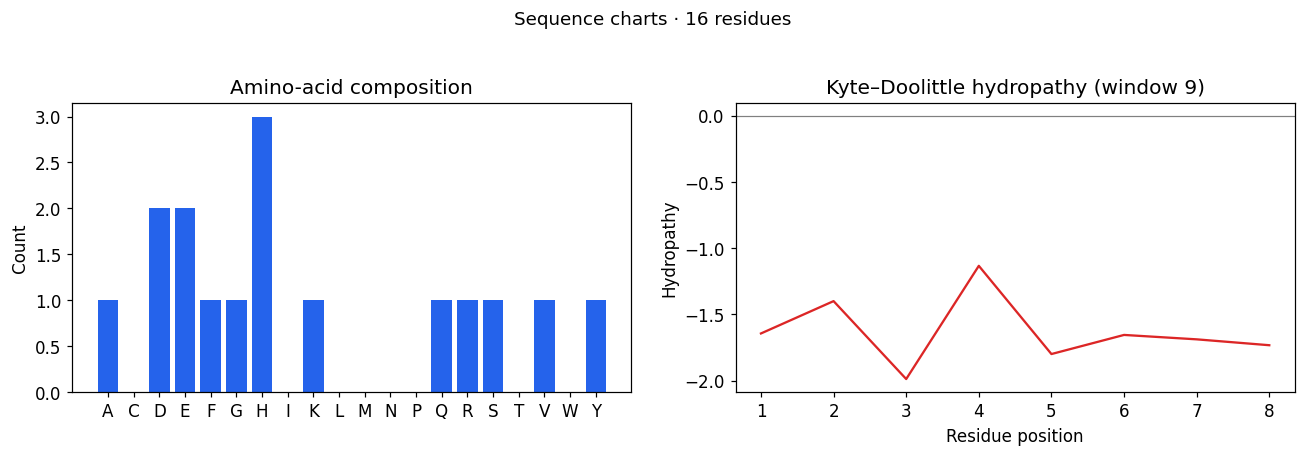

Feature,Value,What it means
Amino acid,"Tryptophan (Trp, W)",Residue identity
Molecular weight (Da),204.230000,Free amino-acid mass
Isoelectric point (pI),5.890000,pH of zero net charge
Hydropathy (Kyte–Doolittle),-0.900000,+ hydrophobic / − hydrophilic
Side-chain class,nonpolar,Polarity / charge


In [ ]:
# --- Example outputs (static preview) -----------------------------------------
analyze_sequence("DAEFRHDSGYEVHHQK")   # beta-amyloid fragment
chart_sequence("DAEFRHDSGYEVHHQK")
analyze_sequence("W")                   # single residue fallback

## Part 2 · Molecule features  (SMILES)

**RDKit** provides the interpretable, structure-aware descriptors (molecular weight, LogP, TPSA, hydrogen-bond counts, QED drug-likeness, Lipinski rule-of-five, Murcko scaffold) plus a 2-D depiction. **mordredcommunity** (the maintained Mordred fork) generates the full **1613-descriptor** 2-D vector.

*Batch mode:* upload a file with a `smiles` column to get the full 1613-feature matrix for every molecule as an Excel workbook.

In [ ]:
# @title
# === PART 2 \u00b7 Small-molecule features (SMILES) ============================
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, Crippen, Lipinski, QED, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from mordred import Calculator, descriptors as _mordred_desc

SMILES_COLS = ["smiles", "smile", "structure", "canonical_smiles", "smiles_string"]
_MORDRED = Calculator(_mordred_desc, ignore_3D=True)   # 1613 2-D descriptors


def analyze_smiles(s):
    mol = Chem.MolFromSmiles(str(s).strip())
    if mol is None:
        print("Could not parse that SMILES \u2014 check the string."); return
    mw, logp = Descriptors.MolWt(mol), Crippen.MolLogP(mol)
    hbd, hba = Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    render_feature_table([
        ("Canonical SMILES", Chem.MolToSmiles(mol), "RDKit-normalised structure"),
        ("Formula", rdMolDescriptors.CalcMolFormula(mol), "Molecular formula"),
        ("Molecular weight", round(mw, 2), "g/mol"),
        ("LogP (Crippen)", round(logp, 2), "Lipophilicity"),
        ("TPSA", round(rdMolDescriptors.CalcTPSA(mol), 2), "Polar surface area (\u00c5\u00b2)"),
        ("H-bond donors", hbd, "Lipinski rule: \u2264 5"),
        ("H-bond acceptors", hba, "Lipinski rule: \u2264 10"),
        ("Rotatable bonds", Descriptors.NumRotatableBonds(mol), "Flexibility"),
        ("Aromatic rings", rdMolDescriptors.CalcNumAromaticRings(mol), "Ring count"),
        ("Heavy atoms", mol.GetNumHeavyAtoms(), "Non-H atoms"),
        ("QED", round(QED.qed(mol), 3), "Drug-likeness, 0\u20131"),
        ("Lipinski violations", viol, "Ro5: 0\u20131 typical for drugs"),
        ("Murcko scaffold", MurckoScaffold.MurckoScaffoldSmiles(mol=mol), "Core ring system")],
        caption="Molecular descriptors")
    display(Draw.MolToImage(mol, size=(360, 260)))


def full_smiles_vector(s):
    mol = Chem.MolFromSmiles(str(s).strip())
    if mol is None:
        print("Could not parse that SMILES."); return
    df = _MORDRED.pandas([mol]).apply(pd.to_numeric, errors="coerce")
    df.insert(0, "SMILES", Chem.MolToSmiles(mol))
    download_dataframe(df, "part2_molecule_features.csv")


def batch_smiles(df, col):
    keep, mols, failed = [], [], []
    for s in df[col].astype(str):
        s = s.strip()
        if not s or s.lower() == "nan":
            continue
        m = Chem.MolFromSmiles(s)
        if m is None:
            failed.append(s)
        else:
            mols.append(m); keep.append(Chem.MolToSmiles(m))
    if not mols:
        print("No valid SMILES found in that column."); return
    feat = _MORDRED.pandas(mols).apply(pd.to_numeric, errors="coerce")
    feat.insert(0, "input_SMILES", keep)
    write_excel(feat, "part2_molecule_FULL_features.xlsx", failed)


def chart_smiles(s):
    import numpy as np
    mol = Chem.MolFromSmiles(str(s).strip())
    if mol is None:
        print("Parse a valid SMILES first."); return
    mw, logp = Descriptors.MolWt(mol), Crippen.MolLogP(mol)
    hbd, hba = Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    labels = ["MW/500", "LogP/5", "HBD/5", "HBA/10", "TPSA/140"]
    ratios = [max(0, mw / 500), max(0, logp / 5), hbd / 5, hba / 10, tpsa / 140]
    ang = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
    vals = ratios + ratios[:1]
    fig = plt.figure(figsize=(6.6, 7.2))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.plot(ang, vals, color="#2563eb", linewidth=2)
    ax.fill(ang, vals, alpha=0.25, color="#2563eb")
    ax.plot(ang, [1] * len(ang), "--", color="#dc2626", linewidth=1.5,
            label="Rule-of-5 limit  (inside the ring = passes)")
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=11)
    ax.set_rlabel_position(36); ax.set_ylim(0, max(1.25, max(vals) * 1.1))
    fig.suptitle("Drug-likeness vs. rule-of-5", y=0.97, fontsize=14, fontweight="bold")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), frameon=False, fontsize=10)
    fig.subplots_adjust(top=0.84, bottom=0.15, left=0.10, right=0.90)
    save_and_show(fig, "chart_molecule_druglikeness.png")


Feature,Value,What it means
Canonical SMILES,CC(=O)Oc1ccccc1C(=O)O,RDKit-normalised structure
Formula,C9H8O4,Molecular formula
Molecular weight,180.160000,g/mol
LogP (Crippen),1.310000,Lipophilicity
TPSA,63.600000,Polar surface area (Å²)
H-bond donors,1,Lipinski rule: ≤ 5
H-bond acceptors,3,Lipinski rule: ≤ 10
Rotatable bonds,2,Flexibility
Aromatic rings,1,Ring count
Heavy atoms,13,Non-H atoms


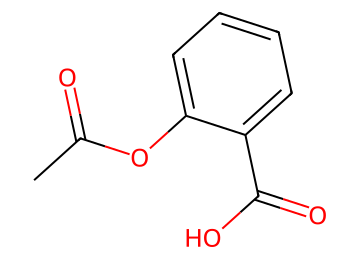

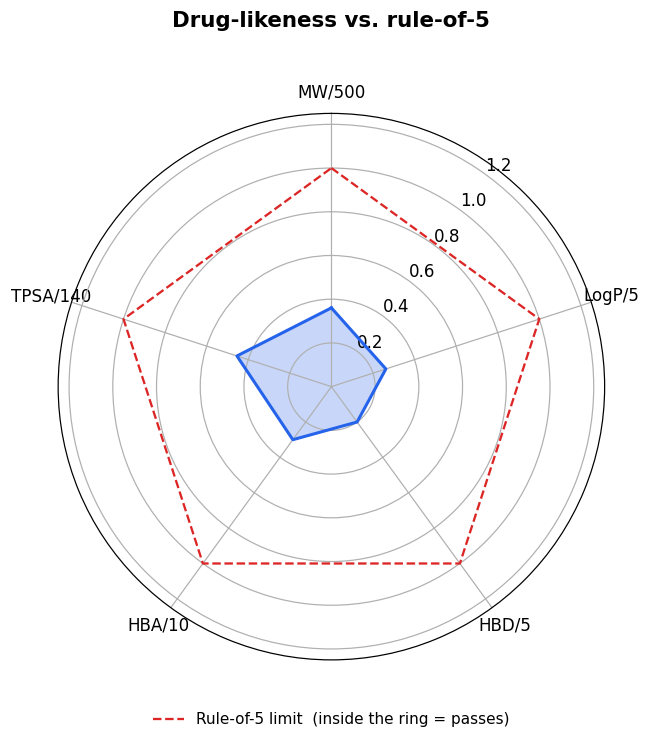

In [ ]:
# --- Example outputs (static preview) -----------------------------------------
analyze_smiles("CC(=O)Oc1ccccc1C(=O)O")   # aspirin (with 2-D depiction)
chart_smiles("CC(=O)Oc1ccccc1C(=O)O")

## Part 3 · Material features  (chemical formula and/or CIF structure)

Two complementary sub-tools that share one install:

- **3a · Composition** — from a formula alone (e.g. `LiFePO4`). Uses **pymatgen** + **matminer** Magpie element-property statistics, valence-orbital fractions, and stoichiometry norms (142 features).
- **3b · Structure (CIF)** — from a crystal file. Uses **pymatgen** to parse and **matminer** `DensityFeatures` / `GlobalSymmetryFeatures`, plus an optional **DScribe SOAP** fingerprint.

> ⚠ matminer is built for **inorganic** compositions and crystals. Rule of thumb: *organic / connectivity matters → Part 2 (SMILES); oxide, alloy, crystal → Part 3.* This is the heaviest install (pymatgen + ASE) — allow a couple of minutes.

*Batch mode (composition):* upload a file with a `formula` column to get the full 142-feature matrix for every compound as an Excel workbook.

In [ ]:
# @title
# === PART 3 \u00b7 Material features (composition + CIF structure) =============
import numpy as np
from pymatgen.core import Composition, Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from matminer.featurizers.composition import ElementProperty, ValenceOrbital, Stoichiometry

_ep = ElementProperty.from_preset("magpie")
_vo = ValenceOrbital(props=["frac"])
_st = Stoichiometry()
FORMULA_COLS = ["formula", "composition", "compound", "formulae", "compounds", "material"]

CURATED_MAGPIE = [
    ("MagpieData mean Number", "Mean atomic number"),
    ("MagpieData mean AtomicWeight", "Mean atomic weight"),
    ("MagpieData mean Electronegativity", "Mean Pauling electronegativity"),
    ("MagpieData mean CovalentRadius", "Mean covalent radius (pm)"),
    ("MagpieData mean NValence", "Mean valence-electron count"),
    ("MagpieData avg_dev Electronegativity", "Spread of electronegativity")]


def featurize_composition_full(formula):
    try:
        comp = Composition(formula)
    except Exception:
        return None
    d = {}
    for f in (_ep, _vo, _st):
        d.update(dict(zip(f.feature_labels(), f.featurize(comp))))
    return d


# ---- 3a composition ----------------------------------------------------------
def analyze_composition(formula):
    try:
        comp = Composition(formula)
    except Exception as e:
        print("Could not parse formula:", e); return
    ep = dict(zip(_ep.feature_labels(), _ep.featurize(comp)))
    vo = dict(zip(_vo.feature_labels(), _vo.featurize(comp)))
    rows = [
        ("Reduced formula", comp.reduced_formula, "Normalised composition"),
        ("Elements", ", ".join(sorted(e.symbol for e in comp.elements)), "Constituents"),
        ("Atoms / formula unit", round(comp.num_atoms, 3), "Total atoms"),
        ("Avg atomic mass", round(float(comp.weight) / comp.num_atoms, 3), "amu per atom")]
    for lbl, meaning in CURATED_MAGPIE:
        if lbl in ep:
            rows.append((lbl.replace("MagpieData ", "Magpie "), round(ep[lbl], 3), meaning))
    for lbl in _vo.feature_labels():
        rows.append((lbl, round(vo[lbl], 3), "Fraction of valence e\u207b in this orbital"))
    render_feature_table(rows, caption=f"Composition features \u00b7 {comp.reduced_formula}")


def full_composition_vector(formula):
    d = featurize_composition_full(formula)
    if d is None:
        print("Could not parse that formula."); return
    df = pd.DataFrame([d]); df.insert(0, "formula", Composition(formula).reduced_formula)
    download_dataframe(df, "part3_composition_features.csv")


def batch_compositions(df, col):
    rows, failed = [], []
    for v in df[col].astype(str):
        v = v.strip()
        if not v or v.lower() == "nan":
            continue
        d = featurize_composition_full(v)
        if d is None:
            failed.append(v); continue
        rows.append({"input_formula": v, **d})
    if not rows:
        print("No valid formulas found in that column."); return
    write_excel(pd.DataFrame(rows), "part3_composition_FULL_features.xlsx", failed)


def chart_composition(formula):
    try:
        comp = Composition(formula)
    except Exception as e:
        print("Could not parse formula:", e); return
    fr = comp.fractional_composition.get_el_amt_dict()
    els = list(fr.keys())
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(els, [fr[e] for e in els], color="#0891b2")
    ax.set_title(f"Atomic fraction \u00b7 {comp.reduced_formula}")
    ax.set_ylabel("Fraction"); ax.set_ylim(0, 1)
    fig.tight_layout()
    save_and_show(fig, "chart_composition.png")


# ---- 3b structure / CIF ------------------------------------------------------
NACL = Structure.from_spacegroup("Fm-3m", Lattice.cubic(5.64),
                                 ["Na", "Cl"], [[0, 0, 0], [0.5, 0.5, 0.5]])


def analyze_structure(st):
    sga = SpacegroupAnalyzer(st)
    a, b, c = st.lattice.abc
    render_feature_table([
        ("Formula", st.composition.reduced_formula, "Structure composition"),
        ("Sites in cell", len(st), "Atoms in the unit cell"),
        ("Density (g/cm\u00b3)", round(float(st.density), 3), "Mass / volume"),
        ("Cell volume (\u00c5\u00b3)", round(st.volume, 2), "Unit-cell volume"),
        ("Volume / atom (\u00c5\u00b3)", round(st.volume / len(st), 2), "Packing measure"),
        ("Lattice a,b,c (\u00c5)", f"{a:.3f}, {b:.3f}, {c:.3f}", "Cell edge lengths"),
        ("Space group", f"{sga.get_space_group_symbol()} (#{sga.get_space_group_number()})", "Symmetry"),
        ("Crystal system", sga.get_crystal_system(), "Lattice family")],
        caption="Crystal-structure features")


def full_structure_vector(st, with_soap=False):
    from matminer.featurizers.structure import DensityFeatures, GlobalSymmetryFeatures
    data = {}
    for f in (DensityFeatures(), GlobalSymmetryFeatures()):
        try:
            data.update(dict(zip(f.feature_labels(), f.featurize(st))))
        except Exception as e:
            print("skipped", f.__class__.__name__, ":", e)
    if with_soap:
        from dscribe.descriptors import SOAP
        from pymatgen.io.ase import AseAtomsAdaptor
        atoms = AseAtomsAdaptor.get_atoms(st)
        species = sorted(set(atoms.get_chemical_symbols()))
        soap = SOAP(species=species, r_cut=5.0, n_max=6, l_max=4, periodic=True)
        vec = soap.create(atoms).mean(axis=0)
        data.update({f"SOAP_{i}": v for i, v in enumerate(vec)})
    df = pd.DataFrame([data]); df.insert(0, "formula", st.composition.reduced_formula)
    download_dataframe(df, "part3_structure_features.csv")


def chart_structure(st):
    a, b, c = st.lattice.abc
    fr = st.composition.fractional_composition.get_el_amt_dict()
    els = list(fr.keys())
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].bar(els, [fr[e] for e in els], color="#0891b2")
    ax[0].set_title(f"Atomic fraction \u00b7 {st.composition.reduced_formula}")
    ax[0].set_ylabel("Fraction"); ax[0].set_ylim(0, 1)
    ax[1].bar(["a", "b", "c"], [a, b, c], color="#7c3aed")
    ax[1].set_title("Lattice parameters (\u00c5)")
    fig.tight_layout()
    save_and_show(fig, "chart_structure.png")


def load_structure(cif_text):
    return Structure.from_str(cif_text, fmt="cif")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature,Value,What it means
Reduced formula,LiFePO4,Normalised composition
Elements,"Fe, Li, O, P",Constituents
Atoms / formula unit,7.000000,Total atoms
Avg atomic mass,22.537000,amu per atom
Magpie mean Number,10.857000,Mean atomic number
Magpie mean AtomicWeight,22.537000,Mean atomic weight
Magpie mean Electronegativity,2.680000,Mean Pauling electronegativity
Magpie mean CovalentRadius,90.143000,Mean covalent radius (pm)
Magpie mean NValence,5.429000,Mean valence-electron count
Magpie avg_dev Electronegativity,0.869000,Spread of electronegativity


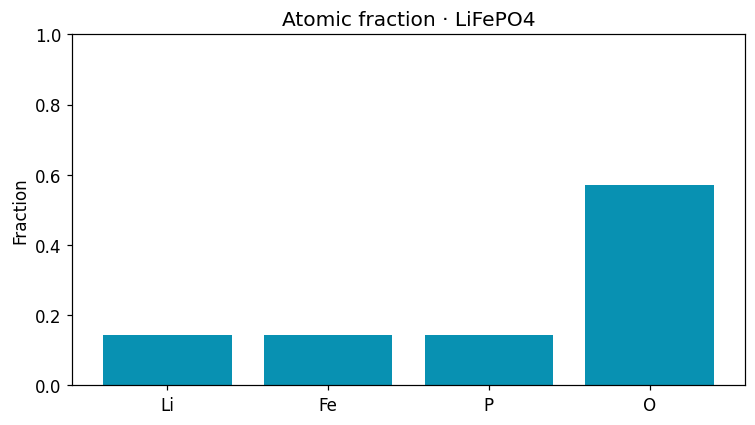

Feature,Value,What it means
Formula,NaCl,Structure composition
Sites in cell,8,Atoms in the unit cell
Density (g/cm³),2.164000,Mass / volume
Cell volume (Å³),179.410000,Unit-cell volume
Volume / atom (Å³),22.430000,Packing measure
"Lattice a,b,c (Å)","5.640, 5.640, 5.640",Cell edge lengths
Space group,Fm-3m (#225),Symmetry
Crystal system,cubic,Lattice family


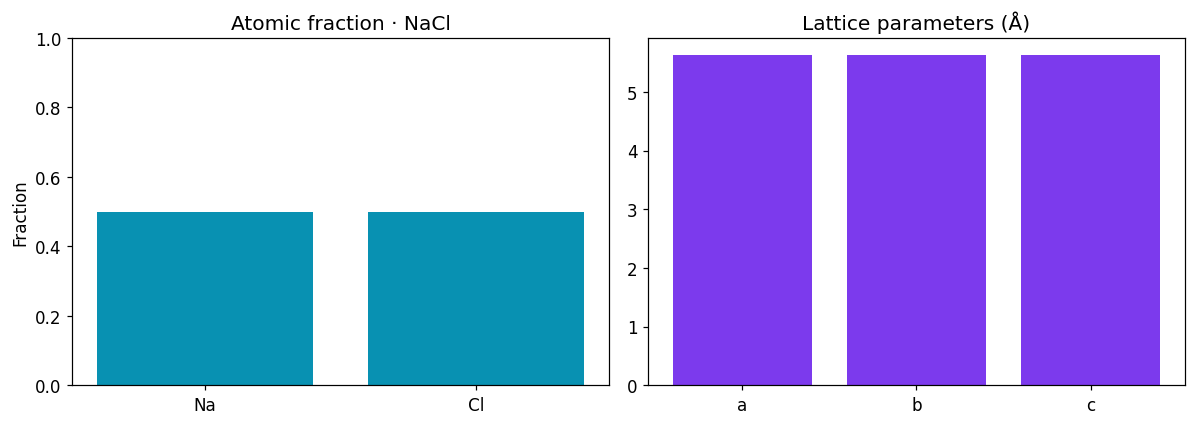

In [ ]:
# --- Example outputs (static preview) -----------------------------------------
analyze_composition("LiFePO4")
chart_composition("LiFePO4")
analyze_structure(NACL)                 # built-in NaCl crystal example
chart_structure(NACL)